In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np 
import pandas as pd
import seaborn as sns

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata)

adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(['leukemic blast'])
adata.uns['cell_type_colors'] = np.append(adata.uns['cell_type_colors'], ['#000000'])

### label clusters in the leukemic blast
adata.obs.loc[adata.obs['pheno_leiden'].isin([4,9,16,13,15,17]) & ~(adata.obs['cell_type'].isin(['B cell (non-HSPC)', 'T cell (non-HSPC)'])), 'cell_type'] = 'leukemic blast'

adata.obs['clone'] = pd.read_csv('../output/clone_assignments.csv', index_col=0)['clone']

In [3]:
color_palette = {ct: color for ct, color in zip(adata.obs['cell_type'].cat.categories, adata.uns['cell_type_colors'])}

/tmp/ipykernel_232077/2039385808.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, ha='right')


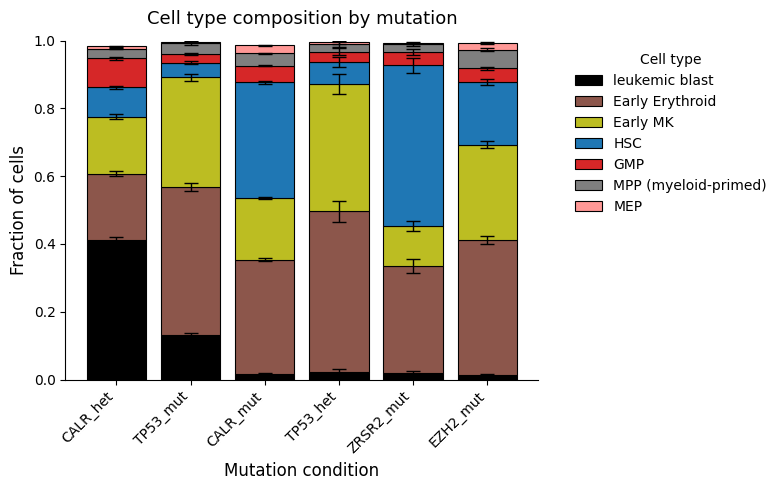

In [4]:
# Define mutation conditions and their labels
conditions = [
    ((adata.obsm['genotype_call']['TP53 c.818G>A'] == 'mutated') & (adata.obsm['genotypes']['TP53 c.818G>A_mutated'] > 0.9)),
    ((adata.obsm['genotype_call']['TP53 c.818G>A'] == 'heterozygous') & (adata.obsm['genotypes']['TP53 c.818G>A_heterozygous'] > 0.9)),
    (adata.obsm['genotype_call']['EZH2 c.2054G>A'].isin(['mutated','heterozygous'])),
    (adata.obsm['genotype_call']['ZRSR2 c.883C>T'].isin(['mutated','heterozygous'])),
    ((adata.obsm['genotype_call']['CALR c.1150_1154delinsTGTC'] == 'heterozygous') & (adata.obsm['genotypes']['CALR c.1150_1154delinsTGTC_heterozygous'] > 0.9)),
    ((adata.obsm['genotype_call']['CALR c.1150_1154delinsTGTC'] == 'mutated') & (adata.obsm['genotypes']['CALR c.1150_1154delinsTGTC_mutated'] > 0.9))
]
labels = ['TP53_mut','TP53_het','EZH2_mut', 'ZRSR2_mut', 'CALR_het', 'CALR_mut']

### get SEM for each cell type fraction
# Build cell-type frequency table (not normalized)
freq_df = []
for cond, label in zip(conditions, labels):
    subset = adata[cond].obs['cell_type'].value_counts(normalize=False)
    tmp = pd.DataFrame(subset).reset_index()
    tmp.columns = ['cell_type', 'fraction']
    tmp['condition'] = label
    freq_df.append(tmp)

freq_df = pd.concat(freq_df)

# Pivot into wide format
plot_df = freq_df.pivot_table(index='condition', columns='cell_type', values='fraction', fill_value=0)
plot_df = plot_df.sort_values('leukemic blast',ascending=False)
plot_df = plot_df[plot_df.iloc[0].sort_values(ascending=False).index]
pre_normalization_plot_df = plot_df.copy()
p_hat = plot_df.div(plot_df.sum(axis=1), axis=0)
se = np.sqrt((p_hat * (1 - p_hat)).div(plot_df.sum(axis=1), axis=0))

## then normalize for plotting
plot_df = plot_df.div(plot_df.sum(axis=1), axis=0).copy()
plot_df = plot_df.sort_values('leukemic blast',ascending=False)
plot_df = plot_df[plot_df.iloc[0].sort_values(ascending=False).index]
plot_df = plot_df.loc[:,plot_df.max() > 0.01].copy()
plot_df = plot_df.reindex(labels=['CALR_het','TP53_mut','CALR_mut','TP53_het','ZRSR2_mut','EZH2_mut'])

se = se.loc[plot_df.index,plot_df.columns].copy()
pre_normalization_plot_df = pre_normalization_plot_df.loc[plot_df.index, plot_df.columns].copy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(plot_df))
for cell_type in plot_df.columns:
    vals = plot_df[cell_type].values
    color = color_palette.get(cell_type, 'gray')  # fallback color
    ax.bar(plot_df.index, vals, bottom=bottom, color=color, edgecolor='k', linewidth=0.8, label=cell_type, yerr=se[cell_type].values, capsize=5, error_kw={'elinewidth': 1, 'ecolor': 'black'})
    bottom += vals

# Styling
ax.set_ylabel('Fraction of cells', fontsize=12)
ax.set_xlabel('Mutation condition', fontsize=12)
ax.set_title('Cell type composition by mutation', fontsize=13, pad=12)
ax.set_ylim(0, 1)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right')

# Legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cell type', frameon=False)
sns.despine()

plt.tight_layout()

plt.savefig('../plots/cell_type_composition_by_mutation.pdf', dpi=300)

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


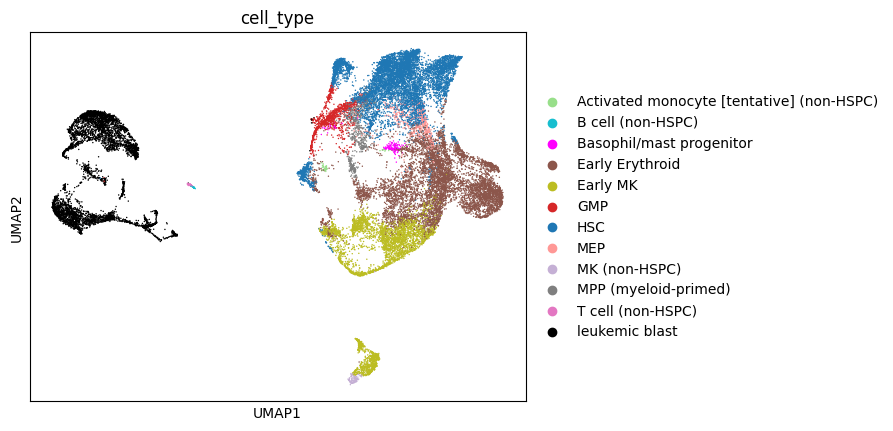

In [5]:
fig,ax = plt.subplots()

cell_types_to_show = adata.obs['cell_type'].value_counts()

sc.pl.umap(adata[adata.obs['cell_type'].isin(cell_types_to_show[cell_types_to_show > 50].index)], color = 'cell_type', ax=ax, show=False)

plt.savefig('../plots/cell_type_umap.pdf', bbox_inches='tight')

In [6]:
## check number of cells
len(adata[adata.obs['cell_type'].isin(cell_types_to_show[cell_types_to_show > 50].index)].obs)

28193